In [ ]:
from google.colab import files
import pandas as pd

# Upload file manually in Google Colab
uploaded = files.upload()

Saving CMOS_LNA_Dataset.csv to CMOS_LNA_Dataset (1).csv


In [ ]:
filename = list(uploaded.keys())[0]  # Automatically get uploaded file name
df = pd.read_csv(filename)

# Display basic info and first few rows
print("Dataset Information:\n", df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature_C    10000 non-null  float64
 1   Frequency_GHz    10000 non-null  float64
 2   Gain_dB          10000 non-null  float64
 3   Noise Figure_dB  10000 non-null  float64
dtypes: float64(4)
memory usage: 312.6 KB
Dataset Information:
 None


,Temperature_C,Frequency_GHz,Gain_dB,Noise Figure_dB
0,-40.000000,3.0,29.966256,1.295962
1,-38.585859,3.0,29.372688,1.203598
2,-37.171717,3.0,29.394864,1.307586
3,-35.757576,3.0,29.968114,1.453391
4,-34.343434,3.0,29.380250,1.090727


In [ ]:
# Checking for missing values
print("Missing values:\n", df.isnull().sum())

# If missing values exist, we can fill them (modify as needed)
df.fillna(df.mean(), inplace=True)

# Display cleaned dataset
df.head()


Missing values:
 Temperature_C      0
Frequency_GHz      0
Gain_dB            0
Noise Figure_dB    0
dtype: int64


,Temperature_C,Frequency_GHz,Gain_dB,Noise Figure_dB
0,-40.000000,3.0,29.966256,1.295962
1,-38.585859,3.0,29.372688,1.203598
2,-37.171717,3.0,29.394864,1.307586
3,-35.757576,3.0,29.968114,1.453391
4,-34.343434,3.0,29.380250,1.090727


In [ ]:
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)  # 25th percentile
    Q3 = df.quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1          # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep only the values within the bounds
    df_cleaned = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

    return df_cleaned

# Remove outliers from dataset
df_cleaned = remove_outliers_iqr(df)

# Print before and after shape
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_cleaned.shape}")

# Save the cleaned dataset if needed
df_cleaned.to_csv("D:\SEM 4\ML Lab\CMOS_LNA_Dataset.csv", index=False)

Original dataset shape: (10000, 4)
Dataset shape after outlier removal: (9901, 4)


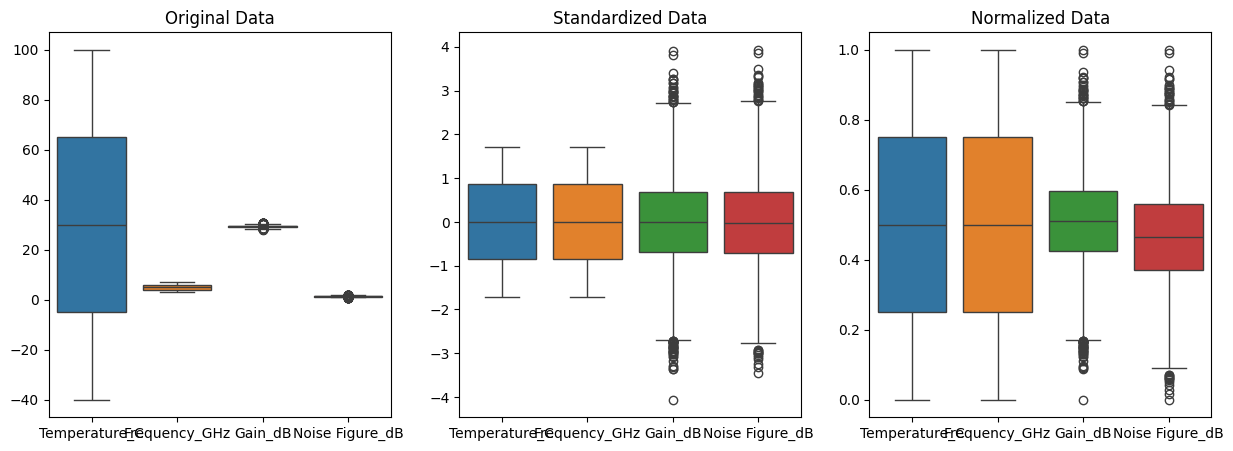

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Copy original data
df_original = df.copy()

# Standardization
scaler_standard = StandardScaler()
df_standardized = pd.DataFrame(scaler_standard.fit_transform(df), columns=df.columns)

# Normalization
scaler_minmax = MinMaxScaler()
df_normalized = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)

# Visualization of transformations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_original, ax=axes[0])
axes[0].set_title("Original Data")

sns.boxplot(data=df_standardized, ax=axes[1])
axes[1].set_title("Standardized Data")

sns.boxplot(data=df_normalized, ax=axes[2])
axes[2].set_title("Normalized Data")

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Define inputs (X) and outputs (Y)
X = df[['Temperature_C', 'Frequency_GHz']]  # Input features
Y = df[['Noise Figure_dB', 'Gain_dB']]  # Output features

# Train-test split (80-20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape, Y_train.shape)
print("Testing set:", X_test.shape, Y_test.shape)


Training set: (8000, 2) (8000, 2)
Testing set: (2000, 2) (2000, 2)


In [ ]:
!pip install keras-tuner

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.regularizers import l2
import keras_tuner as kt

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 144.0921 - mae: 8.7116 - val_loss: 57.2350 - val_mae: 4.7348
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 39.4017 - mae: 3.9376 - val_loss: 17.0413 - val_mae: 2.5425
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 15.1975 - mae: 2.4299 - val_loss: 13.6500 - val_mae: 2.3431
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13.2187 - mae: 2.2965 - val_loss: 12.8517 - val_mae: 2.2369
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 12.3896 - mae: 2.2079 - val_loss: 11.9719 - val_mae: 2.1576
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 11.4225 - mae: 2.1263 - val_loss: 11.1101 - val_mae: 2.1080
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 10.8245 - mae: 2.0701 - val_loss: 10.2076 - val_mae: 1.9931
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.7592 - mae: 1.9705 - val_loss: 9.1316 - val_mae: 1.8979
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s

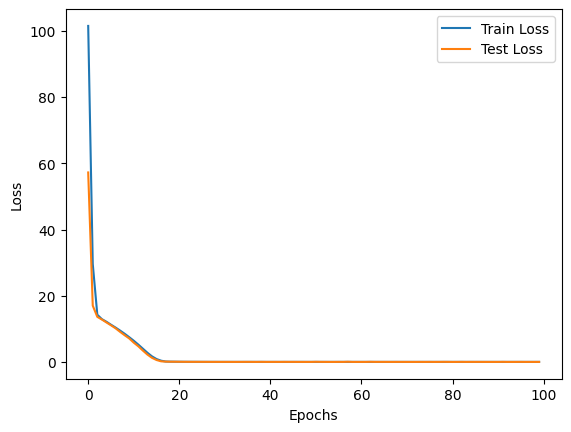

In [ ]:
from tensorflow.keras.optimizers import Adam
# Define the ANN model
model = Sequential([
    Dense(10, input_dim=2, activation='relu'),
    Dense(10, activation='relu'),
    Dense(2, activation='linear')  # Two outputs: Noise & Gain
])

# Compile model with Bayesian Regularization-inspired optimizer
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, Y_train, epochs=100, validation_data=(X_test, Y_test), verbose=1)

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Evaluate the model
train_loss, train_mae = model.evaluate(X_train, Y_train)
test_loss, test_mae = model.evaluate(X_test, Y_test)

print(f"Training MAE: {train_mae:.4f}")
print(f"Testing MAE: {test_mae:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0584 - mae: 0.1734
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0576 - mae: 0.1749
Training MAE: 0.1734
Testing MAE: 0.1742


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Predict on training and test data
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

# Calculate Mean Absolute Percentage Error (MAPE)
train_mape = mean_absolute_percentage_error(Y_train, Y_train_pred) * 100
test_mape = mean_absolute_percentage_error(Y_test, Y_test_pred) * 100

# Calculate R² Score
train_r2 = r2_score(Y_train, Y_train_pred)
test_r2 = r2_score(Y_test, Y_test_pred)

# Print accuracy results
print(f"Training Accuracy (100 - MAPE): {100 - train_mape:.2f}%")
print(f"Testing Accuracy (100 - MAPE): {100 - test_mape:.2f}%")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training Accuracy (100 - MAPE): 95.90%
Testing Accuracy (100 - MAPE): 95.74%
Training R² Score: 0.3338
Testing R² Score: 0.3370


In [ ]:
# Function to predict Noise & Gain dynamically
def predict_output(temp, freq):
    input_data = pd.DataFrame([[temp, freq]], columns=['Temperature', 'Frequency'])
    prediction = model.predict(input_data)
    print(f"Predicted Noise: {prediction[0][0]:.2f}, Predicted Gain: {prediction[0][1]:.2f}")

# Example usage (Modify values as needed)
temp_input = float(input("Enter Temperature (°C): "))
freq_input = float(input("Enter Frequency (GHz): "))
predict_output(temp_input, freq_input)

Enter Temperature (°C): 16
Enter Frequency (GHz): 58
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Noise: 7.02, Predicted Gain: 20.79
